In [1]:
# authors
# Nguyen Van A, ...

In [2]:
# warning:
# only custmoze the 3-4-5 blocks

In [3]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def sma(data, n):
    """Calculate the simple moving average for n days."""
    return pd.Series(data).rolling(window=n, min_periods=1).mean().values

In [4]:
# input your data here
home = 'sample_data'
COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

stk = 's1'
A = np.load(f"{home}/{stk}.npy", allow_pickle=True)
P, V = A[:, 2], A[:, 6]

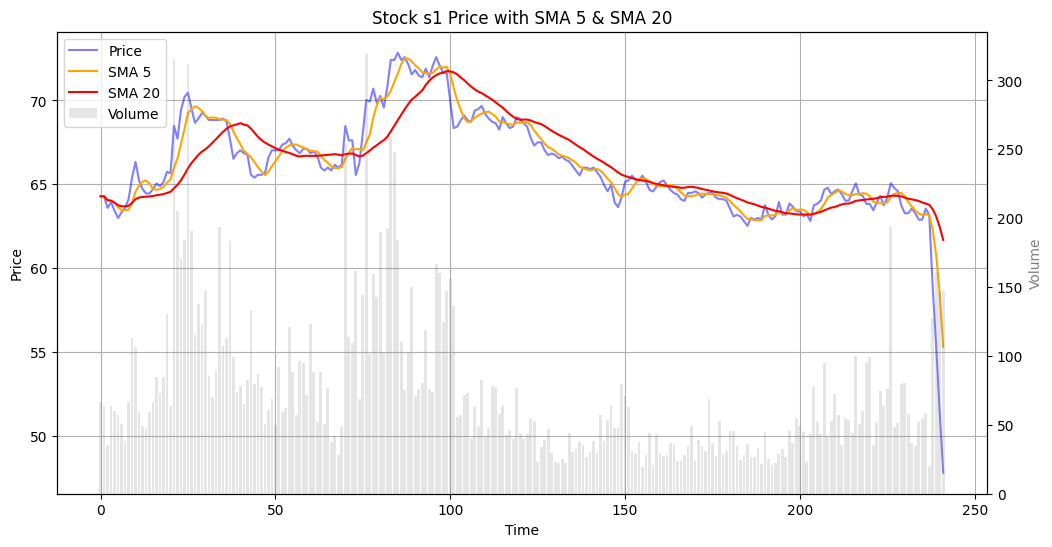

In [5]:
# Visualize
sma5 = sma(P, 5)
sma20 = sma(P, 20)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(P, color='blue', label='Price', alpha=0.5)
ax1.plot(sma5, color='orange', label='SMA 5')
ax1.plot(sma20, color='red', label='SMA 20')
ax1.set_ylabel('Price')
ax1.set_xlabel('Time')
ax1.set_title(f'Stock {stk} Price with SMA 5 & SMA 20')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.bar(range(len(V)), V, color='gray', alpha=0.2, label='Volume')
ax2.set_ylabel('Volume', color='gray')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
bars, bar_labels = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + bar_labels, loc='upper left')

plt.show()

In [6]:
# Data Processing & Interactive Visualization (Close Price, Volume, Trend & Anomalies)
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Convert to DataFrame (Focus on 'cls' and 'vol')
cols = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']
df = pd.DataFrame(A, columns=cols)

# Parse dates (YYYYMMDD format)
df['date'] = pd.to_datetime(df['date'].astype(int).astype(str), format='%Y%m%d')

# Ensure numeric columns are numeric
df['cls'] = pd.to_numeric(df['cls'], errors='coerce')
df['vol'] = pd.to_numeric(df['vol'], errors='coerce')

# 2. Calculate Indicators & Trend Fill Bounds
df['SMA5'] = sma(df['cls'].values, 5)
df['SMA20'] = sma(df['cls'].values, 20)

# Calculate bounds for filling
df['SMA5_Green'] = np.where(df['SMA5'] >= df['SMA20'], df['SMA5'], df['SMA20'])
df['SMA5_Red'] = np.where(df['SMA5'] < df['SMA20'], df['SMA5'], df['SMA20'])

# 3. Identify Anomalies
df['Prev_Cls'] = df['cls'].shift(1)
# Uptrend Anomaly: SMA5 > SMA20 (Uptrend) BUT Price decreased (Price[t] < Price[t-1])
df['Uptrend_Anomaly'] = (df['SMA5'] > df['SMA20']) & (df['cls'] < df['Prev_Cls'])
# Downtrend Anomaly: SMA5 < SMA20 (Downtrend) BUT Price increased (Price[t] > Price[t-1])
df['Downtrend_Anomaly'] = (df['SMA5'] < df['SMA20']) & (df['cls'] > df['Prev_Cls'])

# 4. Interactive Plot
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=(f'Stock {stk} Trend & Anomalies', 'Volume'),
                    row_heights=[0.7, 0.3])

# --- Row 1: Trend Cloud & Price ---
# 1. Base SMA20 (Invisible)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA20'], line=dict(width=0), showlegend=False, hoverinfo='skip'), row=1, col=1)

# 2. Trend Fills
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA5_Green'], 
                         line=dict(width=0), 
                         fill='tonexty', fillcolor='rgba(0, 200, 0, 0.2)', 
                         name='Up Trend', hoverinfo='skip'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA20'], line=dict(width=0), showlegend=False, hoverinfo='skip'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA5_Red'], 
                         line=dict(width=0), 
                         fill='tonexty', fillcolor='rgba(200, 0, 0, 0.2)', 
                         name='Down Trend', hoverinfo='skip'), row=1, col=1)

# 3. Lines
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA20'], line=dict(color='red', width=1.5), name='SMA 20'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA5'], line=dict(color='orange', width=1.5), name='SMA 5'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['cls'], line=dict(color='blue', width=1), name='Close Price'), row=1, col=1)

# 4. Anomalies
anom_up = df[df['Uptrend_Anomaly']]
fig.add_trace(go.Scatter(x=anom_up['date'], y=anom_up['cls'], 
                         mode='markers', marker=dict(color='black', symbol='x', size=6), 
                         name='Uptrend Anomaly (Drop)'), row=1, col=1)

anom_down = df[df['Downtrend_Anomaly']]
fig.add_trace(go.Scatter(x=anom_down['date'], y=anom_down['cls'], 
                         mode='markers', marker=dict(color='purple', symbol='circle-open', size=6), 
                         name='Downtrend Anomaly (Rise)'), row=1, col=1)

# --- Row 2: Volume ---
fig.add_trace(go.Bar(x=df['date'], y=df['vol'], marker_color='gray', name='Volume'), row=2, col=1)

fig.update_layout(title=f'Interactive Analysis: Stock {stk} (Trend Anomalies)', 
                  xaxis_rangeslider_visible=False,
                  height=700,
                  template='plotly_white')

fig.show()

In [7]:
# Summary of Anomalies
total_days = len(df)
uptrend_days = (df['SMA5'] > df['SMA20']).sum()
downtrend_days = (df['SMA5'] < df['SMA20']).sum()

up_anoms = df['Uptrend_Anomaly'].sum()
down_anoms = df['Downtrend_Anomaly'].sum()

print(f"--- Anomaly Summary for {stk} ---")
print(f"Total Trading Days: {total_days}")
print(f"\nUptrend Condition (SMA5 > SMA20):")
print(f"  - Total Days: {uptrend_days}")
print(f"  - Anomalies (Price Drop): {up_anoms} ({up_anoms/uptrend_days*100:.2f}% of Uptrend)")

print(f"\nDowntrend Condition (SMA5 < SMA20):")
print(f"  - Total Days: {downtrend_days}")
print(f"  - Anomalies (Price Rise): {down_anoms} ({down_anoms/downtrend_days*100:.2f}% of Downtrend)")

print(f"\nTotal Anomalies: {up_anoms + down_anoms} ({(up_anoms + down_anoms)/total_days*100:.2f}% of total data)")

--- Anomaly Summary for s1 ---
Total Trading Days: 242

Uptrend Condition (SMA5 > SMA20):
  - Total Days: 103
  - Anomalies (Price Drop): 49 (47.57% of Uptrend)

Downtrend Condition (SMA5 < SMA20):
  - Total Days: 134
  - Anomalies (Price Rise): 52 (38.81% of Downtrend)

Total Anomalies: 101 (41.74% of total data)


In [8]:
# New Strategy: SMA Gap Momentum Logic
# Calculate the difference (gap) between SMA5 and SMA20
df['SMA_Diff'] = df['SMA5'] - df['SMA20']
# Calculate the daily change in the gap
df['Diff_Change'] = df['SMA_Diff'] - df['SMA_Diff'].shift(1)

def define_gap_strategy(row):
    diff = row['SMA_Diff']
    change = row['Diff_Change']
    
    if pd.isna(diff) or pd.isna(change):
        return 'Unknown', 'lightgray'
    
    # User's specific situation (SMA5 < SMA20)
    if diff < 0:
        if change < 0:
            # Gap is becoming more negative (e.g. -0.8 to -0.9)
            return 'Strong Downtrend', 'red'
        else:
            # Gap is becoming less negative (e.g. -0.9 to -0.8) -> Signal Uptrend
            return 'Signal Uptrend (Recovery)', 'green'
    
    # Positive Gap situations (for completeness)
    else:
        if change > 0:
            # Gap is widening positively
            return 'Strong Uptrend', 'darkgreen'
        else:
            # Gap is narrowing
            return 'Signal Downtrend (Drop)', 'orange'

df[['Strategy_Signal', 'Signal_Color']] = df.apply(
    lambda row: pd.Series(define_gap_strategy(row)), axis=1
)

In [9]:
df['Diff_Change'] = df['SMA_Diff'] - df['SMA_Diff'].shift(1)
df['Diff_Change']

0         NaN
1      0.0000
2      0.0000
3      0.0000
4      0.0000
        ...  
237   -0.0150
238   -0.6130
239   -1.0975
240   -1.6765
241   -2.3645
Name: Diff_Change, Length: 242, dtype: float64

In [10]:
# Visualize SMA Gap Strategy
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=(f'Stock {stk} Price & SMAs', 'SMA Gap Momentum (Strategy Signal)'),
                    row_heights=[0.6, 0.4])

# --- Row 1: Price & SMAs ---
fig.add_trace(go.Scatter(x=df['date'], y=df['cls'], line=dict(color='blue', width=1), name='Close Price'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA5'], line=dict(color='orange', width=1), name='SMA 5'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA20'], line=dict(color='red', width=1), name='SMA 20'), row=1, col=1)

# --- Row 2: Gap Bar Chart ---
# We plot the gap as bars, colored by the signal logic
fig.add_trace(go.Bar(x=df['date'], y=df['SMA_Diff'], 
                     marker_color=df['Signal_Color'],
                     name='SMA Gap'), row=2, col=1)

# Add dummy traces for legend to explain colors
fig.add_trace(go.Bar(x=[None], y=[None], marker_color='red', name='Strong Downtrend (Widening -)'), row=2, col=1)
fig.add_trace(go.Bar(x=[None], y=[None], marker_color='green', name='Signal Uptrend (Narrowing -)'), row=2, col=1)
fig.add_trace(go.Bar(x=[None], y=[None], marker_color='darkgreen', name='Strong Uptrend (Widening +)'), row=2, col=1)
fig.add_trace(go.Bar(x=[None], y=[None], marker_color='orange', name='Signal Downtrend (Narrowing +)'), row=2, col=1)

fig.update_layout(title=f'Strategy Analysis: SMA Gap Momentum for {stk}', 
                  xaxis_rangeslider_visible=False,
                  height=800,
                  template='plotly_white',
                  barmode='overlay')

fig.show()

In [11]:
# Anomalies for SMA Gap Momentum Strategy
# Define anomalies based on Strategy Signal vs Price Action

# 1. Strong Downtrend Anomaly: Signal is 'Strong Downtrend' (expect drop) BUT Price ROSE
df['Strat_Down_Anomaly'] = (df['Strategy_Signal'] == 'Strong Downtrend') & (df['cls'] > df['Prev_Cls'])

# 2. Signal Downtrend Anomaly: Signal is 'Signal Downtrend' (expect drop) BUT Price ROSE
df['Strat_SignalDown_Anomaly'] = (df['Strategy_Signal'] == 'Signal Downtrend (Drop)') & (df['cls'] > df['Prev_Cls']) 

# 3. Signal Uptrend Anomaly: Signal is 'Signal Uptrend' (expect recovery/rise) BUT Price DROPPED
df['Strat_SignalUp_Anomaly'] = (df['Strategy_Signal'] == 'Signal Uptrend (Recovery)') & (df['cls'] < df['Prev_Cls'])

# (Optional) Anomalies for positive gap states
# 4. Strong Uptrend Anomaly: Signal 'Strong Uptrend' BUT Price DROPPED
df['Strat_Up_Anomaly'] = (df['Strategy_Signal'] == 'Strong Uptrend') & (df['cls'] < df['Prev_Cls'])

print("--- Strategy Anomaly Summary ---")
print(f"Strong Downtrend Anomalies (Price Rose): {df['Strat_Down_Anomaly'].sum()}")
print(f"Signal Downtrend Anomalies (Price Rose): {df['Strat_SignalDown_Anomaly'].sum()}")
print(f"Signal Uptrend Anomalies (Price Dropped): {df['Strat_SignalUp_Anomaly'].sum()}")
print(f"Strong Uptrend Anomalies (Price Dropped): {df['Strat_Up_Anomaly'].sum()}")

--- Strategy Anomaly Summary ---
Strong Downtrend Anomalies (Price Rose): 21
Signal Downtrend Anomalies (Price Rose): 16
Signal Uptrend Anomalies (Price Dropped): 24
Strong Uptrend Anomalies (Price Dropped): 23


In [12]:
# Visualize Strategy Anomalies
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=(f'Stock {stk} Strategy Anomalies', 'SMA Gap Momentum'),
                    row_heights=[0.7, 0.3])

# --- Row 1: Price & Anomalies ---
fig.add_trace(go.Scatter(x=df['date'], y=df['cls'], line=dict(color='blue', width=1), name='Close Price'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA5'], line=dict(color='orange', width=1), name='SMA 5'), row=1, col=1)
fig.add_trace(go.Scatter(x=df['date'], y=df['SMA20'], line=dict(color='red', width=1), name='SMA 20'), row=1, col=1)

# Anomaly Markers
# Unexpected Drop during 'Signal Uptrend' OR 'Strong Uptrend'
# Use bitwise OR (|) to combine boolean conditions
mask_up_fail = df['Strat_Up_Anomaly'] | df['Strat_StrongUp_Anomaly']
anom_up_fail = df[mask_up_fail]

fig.add_trace(go.Scatter(x=anom_up_fail['date'], y=anom_up_fail['cls'], 
                         mode='markers', marker=dict(color='black', symbol='x', size=7), 
                         name='Uptrend Anomaly (Drop)'), row=1, col=1)

# Unexpected Rise during 'Strong Downtrend'
anom_down_fail = df[df['Strat_Down_Anomaly']]
fig.add_trace(go.Scatter(x=anom_down_fail['date'], y=anom_down_fail['cls'], 
                         mode='markers', marker=dict(color='purple', symbol='circle-open', size=7), 
                         name='Strong Downtrend Anomaly (Rise)'), row=1, col=1)

# --- Row 2: Gap Bar Chart (Context) ---
fig.add_trace(go.Bar(x=df['date'], y=df['SMA_Diff'], 
                     marker_color=df['Signal_Color'],
                     name='SMA Gap'), row=2, col=1)

fig.update_layout(title=f'Strategy Anomalies: {stk} (Gap Momentum)', 
                  xaxis_rangeslider_visible=False,
                  height=800,
                  template='plotly_white')

fig.show()

KeyError: 'Strat_StrongUp_Anomaly'

In [ ]:
# Visualize return

In [ ]:
# customize your prediction
def prediction(P, V):
    def truncate(u):
        # for this market, the maximun return range is -0.07 and 0.07
        v = u
        if v < -0.07:
            u = -0.07
        elif v > 0.07:
            u = 0.07
        return u
    # Q is the array of returns for the next day
    n, Q = len(P), []
    
    return Q

In [ ]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.03  |  abs = 0.05  |  rel = -0.688



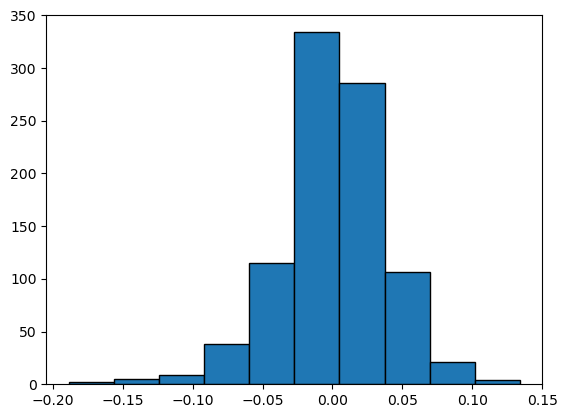

In [ ]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(P, V), target(P, V)
evaluate(p, t, True)